# Plotting

## Motif

In [11]:
adataMotifM = sc.read_h5ad( '../Mlig_Multiome/ArchR_Integration_Outputs/export/Mlig.SEACells_motifs_SHAP_mean_97_20230728.h5ad' )
adataMotifM = adataMotifM[adataPeakM.obs_names,:].copy()
adataMotifM.obs = adataPeakM.obs.copy()
adataMotifM

AnnData object with n_obs × n_vars = 502 × 1269
    obs: 'n_counts', 'GroupFigure', 'TissueSAM', 'Sample', 'SEACell'

In [12]:
adataMotifP = sc.read_h5ad( 'planarian_export/Smed.scvi_motifs_20240321.h5ad' )
adataMotifP = adataMotifP[adataPeakP.obs_names,:].copy()
adataMotifP.obs = adataPeakP.obs.copy()
adataMotifP

AnnData object with n_obs × n_vars = 415 × 1269
    obs: 'n_counts', 'GroupFigure', 'TissueSAM', 'Sample', 'SEACell'

In [13]:
adataMotifS = sc.read_h5ad( 'schisto_export/Sman.SEACells_motifs_SHAP_mean_98_20230803.h5ad' )
adataMotifS = adataMotifS[adataPeakS.obs_names,:].copy()
adataMotifS.obs = adataPeakS.obs.copy()
adataMotifS

AnnData object with n_obs × n_vars = 435 × 1269
    obs: 'n_counts', 'GroupFigure', 'TissueSAM', 'Sample', 'SEACell'

## Gene expression

In [14]:
def loadRNAData( rnaPath, geneBedPath, skipBedRows=0 ):
    adataRNA = sc.read_h5ad( rnaPath )
    adataRNA.var_names = [ n.replace( '-', '_' ) for n in adataRNA.var_names ]
    
    bed = pd.read_table( geneBedPath, header=None, skiprows=skipBedRows )

    bed.columns = ['Chr','Source','Type','Start','Stop','NA1','Strand','NA2','Info']
    bed = bed.loc[bed.Type=='gene']
    bed.index = [ i.split('\"')[1].strip('.gene') for i in bed.Info ]
    bed = bed.loc[:,['Chr','Start','Stop','Strand']]
    adataRNA.var = bed.loc[adataRNA.var_names,:]
    del bed
    gc.collect()

    return adataRNA

In [15]:
adataGexM = loadRNAData( '../Mlig_Multiome/Mlig.SEACells_RNA_pvi_20230710.h5ad',
                         '../Refs/Mlig_4_5.v5/Mlig_RNA_4_5.v5.coregenes.Chew.gtf' )
adataGexM = adataGexM[adataPeakM.obs_names,:].copy()
adataGexM.layers['knnAvg'] = performNearestNeighborAveraging( adataGexM, adataPeakM.obsp['connectivities'] )

adataGexM

AnnData object with n_obs × n_vars = 502 × 71174
    obs: 'n_counts', 'GroupFigure', 'TissueSAM', 'Sample'
    var: 'Chr', 'Start', 'Stop', 'Strand'
    uns: 'log1p'
    layers: 'raw', 'knnAvg'

In [16]:
adataGexP = loadRNAData( 'planarian_export/Smed.SEACells_RNA_scvi_20240319.h5ad',
                         '/media/gary/Chew/Sch_multiome/chromap_all/Smes_SMESG_g4_hc_edit_v04.gtf' )
adataGexP = adataGexP[adataPeakP.obs_names,:].copy()
adataGexP.layers['knnAvg'] = performNearestNeighborAveraging( adataGexP, adataPeakP.obsp['connectivities'] )

adataGexP

AnnData object with n_obs × n_vars = 415 × 22192
    obs: 'n_counts', 'GroupFigure', 'TissueSAM', 'Sample'
    var: 'Chr', 'Start', 'Stop', 'Strand'
    uns: 'log1p'
    layers: 'raw', 'knnAvg'

In [17]:
adataGexS = loadRNAData( 'schisto_export/Sman.SEACells_RNA_impavg_pvi_20230823.h5ad',
                         '/media/gary/Chew/Schisto_ATAC/Chew_ArchR/Schisto_ATAC/schistosoma_mansoni.PRJEA36577.WBPS15.canonical_geneset.gtf',
                         skipBedRows=1 )
adataGexS = adataGexS[adataPeakS.obs_names,:].copy()
adataGexS.layers['knnAvg'] = performNearestNeighborAveraging( adataGexS, adataPeakS.obsp['connectivities'] )

adataGexS

AnnData object with n_obs × n_vars = 435 × 10150
    obs: 'n_counts', 'GroupFigure', 'TissueSAM', 'Sample'
    var: 'Chr', 'Start', 'Stop', 'Strand'
    uns: 'log1p'
    layers: 'raw', 'knnAvg'

In [18]:
X = adataGexS.X.A
for s in ['adult','juvenile']:
    mask = adataGexS.obs.Sample.str.startswith(s)
    x = X[mask,:]
    sds = (x**2).mean(0)**0.5
    sds[sds==0] = 1
    X[mask,:] = x / sds[None,:]
X = np.nan_to_num( X )
adataGexS.layers['batchNorm'] = sparse.csr_matrix( X )

del X
gc.collect()

216

In [28]:
custom_cmap = matplotlib.colors\
                .LinearSegmentedColormap.from_list( 'custom', plt.get_cmap('Reds')\
                                                                    (np.linspace(0,1,100)**(2)) )

fox, hnf4, pou4, nr4, pou, sox, p53

In [25]:
plotMotifs = [ 'JC_0014|FOXI1(0.063)',
               'JC_0417|HNF4G(0.031)',
               'JC_0255|POU4F3(0.087)',
               'WC_1094|NR4A1(0.838)',
               'JC_0180|POU5F1B(0.039)',
               'JC_0197|SOX4(0.087)',
               'JC_0288|TP73(0.268)' ]

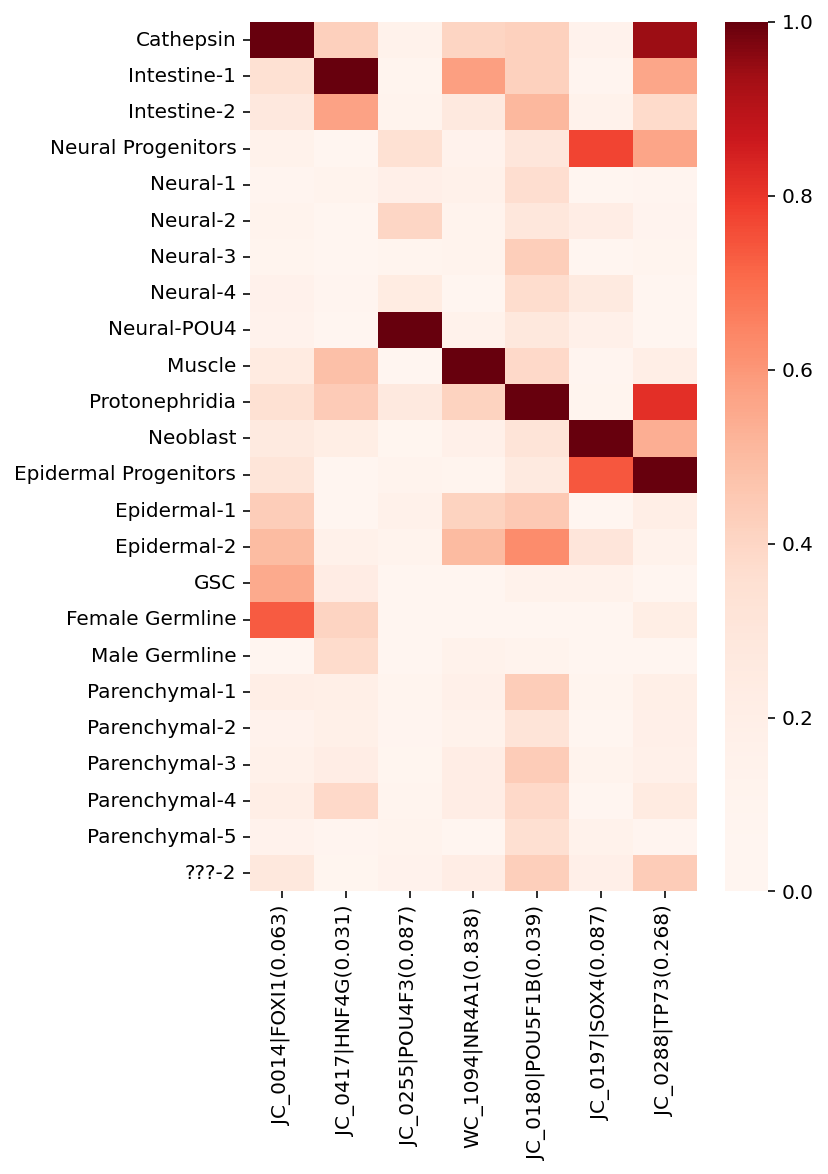

In [41]:
# uLabels = np.array(['Cathepsin','Intestine-1','Intestine-2','GSC','Female Germline','Male Germline','Neoblast',
#                     'Neural Progenitors','Neural-1','Neural-2','Neural-3','Neural-4','Neural-POU4','Muscle','Epidermal Progenitors',
#                     'Epidermal-1','Epidermal-2','Parenchymal-1','Parenchymal-2','Parenchymal-3','Parenchymal-4','Parenchymal-5',
#                     'Protonephridia','???-2'])
uLabels = np.array(['Cathepsin','Intestine-1','Intestine-2', 'Neural Progenitors','Neural-1','Neural-2','Neural-3','Neural-4',
                    'Neural-POU4','Muscle', 'Protonephridia','Neoblast','Epidermal Progenitors','Epidermal-1','Epidermal-2',
                    'GSC','Female Germline','Male Germline','Parenchymal-1','Parenchymal-2','Parenchymal-3','Parenchymal-4','Parenchymal-5',
                    '???-2'])
X = np.zeros( (uLabels.size,len(plotMotifs)) )
for i, grp in enumerate( uLabels ):
    X[i,:] = adataMotifM[adataMotifM.obs.GroupFigure==grp,plotMotifs].X.mean(0)
    
X = pd.DataFrame( data=X, index=uLabels, columns=plotMotifs )
X = X - X.min(0)
X = X / X.max(0)
fig = plt.figure( figsize=(5,8) )
sns.heatmap( X, cmap=custom_cmap, ax=fig.gca() )
plt.savefig( 'Figures/Mlig.cluster_motif_comparison_devs_20250911_trimmed.svg', format='svg' )
plt.show()

In [30]:
mligGeneMap = { 'JC_0014|FOXI1(0.063)':['ML45REF0179:115799-116197'],
                'JC_0012|ELK3(0.088)':['ML45REF0029:2941525-2942120','ML45REF0013:585433-585792'],
                'JC_0417|HNF4G(0.031)':['ML45REF0071:1604780-1605932'],
                'JC_0073|GATA3(0.177)':['ML45REF0003:150675-151438',],
                'JC_0083|NKX2-8(0.092)':['ML45REF0118:5451-6566','ML45REF0222:6153-6918'],
                'JC_0197|SOX4(0.087)':['ML45REF0006:3365967-3366512'],
                'JC_0288|TP73(0.268)':['ML45REF0005:2711117-2711868'], # probably want to zero this one out in the actual plot
                'JC_0255|POU4F3(0.087)':['ML45REF0041:1759400-1759901'],
                'WC_1094|NR4A1(0.838)':['ML45REF0259:318997-319991'],
                'JC_0200|MYOG(0.115)':['ML45REF0097:436211-437187','ML45REF0029:70368-71257'],
                'JC_0341|GATA20(0.052)':['ML45REF0059:2644322-2644977'],
                'JC_0292|Sox11(0.000)':['ML45REF0042:1453288-1453602'],
                'JC_0276|PAX1(0.064)':['ML45REF0032:517812-518783'],
                'JC_0364|FERD3L(0.000)':['ML45REF0094:1610370-1610611'],
                'JC_0180|POU5F1B(0.039)':['ML45REF0031:3596282-3596709'],
                'JC_0176|FOXC2(0.237)':['ML45REF0179:115799-116197','ML45REF0035:2325991-2326455'] }

In [31]:
mligNameMap = { 'ML45REF0179:115799-116197': 'foxF2',
                'ML45REF0029:2941525-2942120': 'ets2',
                'ML45REF0013:585433-585792': 'etv5',
                'ML45REF0071:1604780-1605932': 'hnf4',
                'ML45REF0003:150675-151438': 'gata4',
                'ML45REF0118:5451-6566': 'nkx2-2',
                'ML45REF0222:6153-6918': 'nkx2-2', # this is the one we show in the paper, should we do an a/b thing?
                'ML45REF0006:3365967-3366512': 'sox8',
                'ML45REF0005:2711117-2711868': 'delete',
                'ML45REF0041:1759400-1759901': 'pou4F2',
                'ML45REF0259:318997-319991': 'nr4A2',
                'ML45REF0097:436211-437187': 'tcf4',
                'ML45REF0029:70368-71257': 'myod1',
                'ML45REF0059:2644322-2644977': 'gata4', # this is a different gata4 than intestine - a/b?
                'ML45REF0042:1453288-1453602': 'sox15',
                'ML45REF0032:517812-518783': 'pax5',
                'ML45REF0094:1610370-1610611': 'ferd3l',
                'ML45REF0031:3596282-3596709': 'pou3F2',
                'ML45REF0035:2325991-2326455': 'foxA1' }

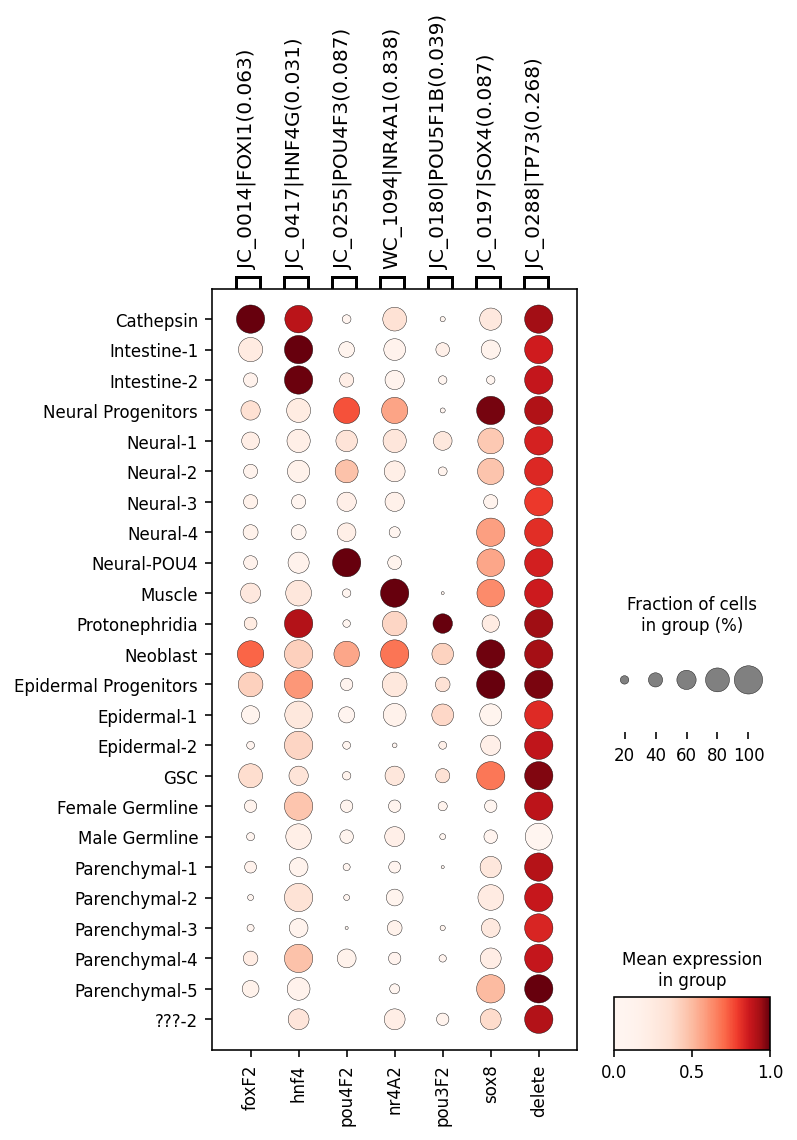

In [42]:
pOrder = np.concatenate( [ mligGeneMap[motif] for motif in plotMotifs ] )
gOrder = [ mligNameMap[p] for p in pOrder ]
intervals = []
i = 0
for motif in plotMotifs:
    n = len( mligGeneMap[motif] )
    j = i + n - 1
    intervals.append( (i,j) )
    i = j + 1
    
g = sc.pl.dotplot( adataPeakM, groupby='GroupFigure', use_raw=False, show=False,
               mean_only_expressed=False, figsize=(5,7), standard_scale='var', 
               dot_min=0, dot_max=1, categories_order=uLabels, # layer='knnAvg',
               var_names=pOrder, cmap=custom_cmap, 
               var_group_labels=plotMotifs, var_group_positions=intervals )
g['mainplot_ax'].set_xticklabels(gOrder)
plt.savefig( 'Figures/Mlig.cluster_motif_comparison_gex_20250911_trimmed.svg', format='svg' )
plt.show()

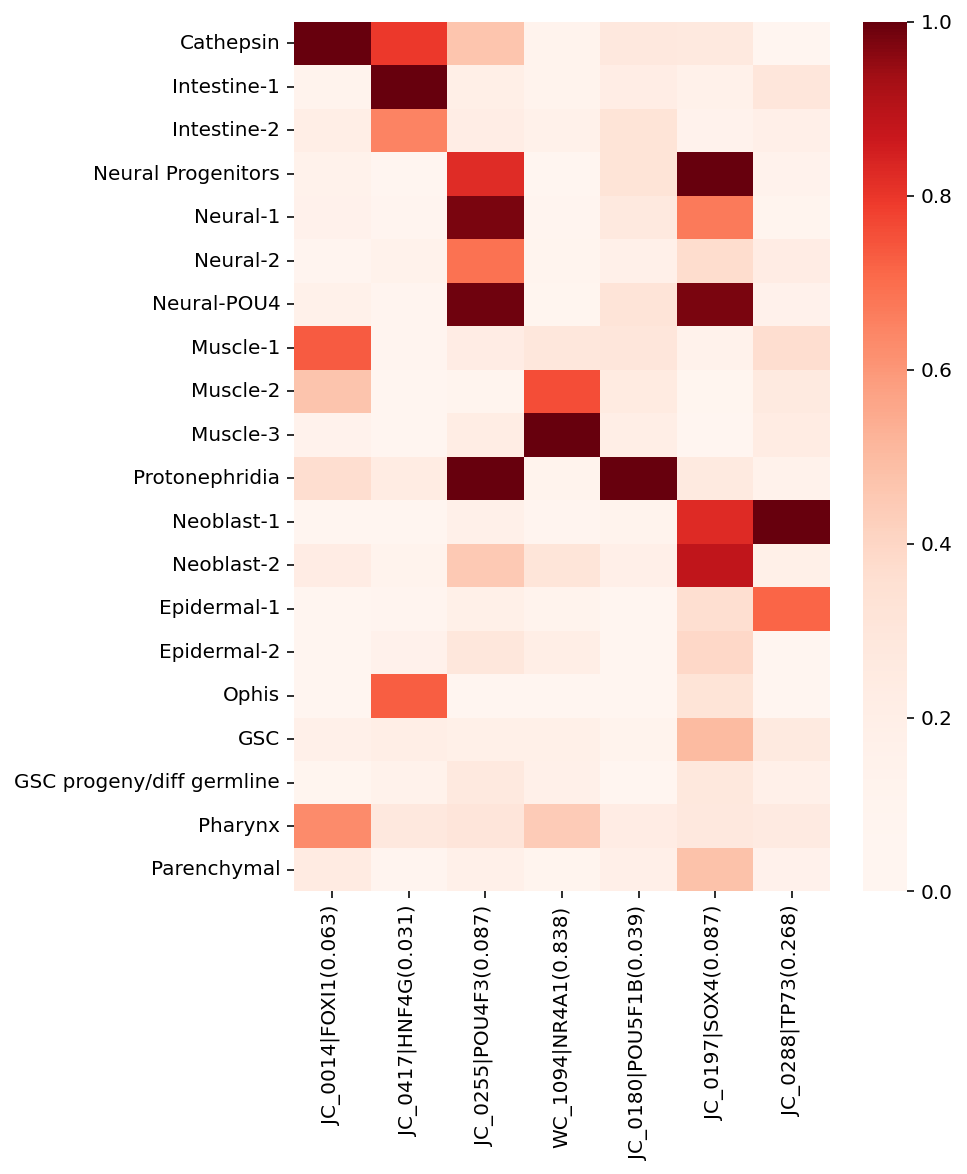

In [43]:
# uLabels = np.array(['Cathepsin','Intestine-1','Intestine-2','Ophis','GSC','GSC progeny/diff germline','Neoblast-1','Neoblast-2',
#                     'Neural Progenitors','Neural-1','Neural-2','Neural-POU4','Muscle-1','Muscle-2','Muscle-3',
#                     'Epidermal-1','Epidermal-2','Pharynx','Parenchymal','Protonephridia'])
uLabels = np.array(['Cathepsin','Intestine-1','Intestine-2','Neural Progenitors','Neural-1','Neural-2',
                    'Neural-POU4','Muscle-1','Muscle-2','Muscle-3','Protonephridia','Neoblast-1','Neoblast-2','Epidermal-1','Epidermal-2',
                    'Ophis','GSC','GSC progeny/diff germline','Pharynx','Parenchymal'])
X = np.zeros( (uLabels.size,len(plotMotifs)) )
for i, grp in enumerate( uLabels ):
    X[i,:] = adataMotifP[adataMotifP.obs.GroupFigure==grp,plotMotifs].X.mean(0)
    
X = pd.DataFrame( data=X, index=uLabels, columns=plotMotifs )
X = X - X.min(0)
X = X / X.max(0)
fig = plt.figure( figsize=(6,8) )
sns.heatmap( X, cmap=custom_cmap, ax=fig.gca() )
plt.savefig( 'Figures/Smed.cluster_motif_comparison_devs_20250911_trimmed.svg', format='svg' )
plt.show()

In [34]:
smedGeneMap = { 'JC_0014|FOXI1(0.063)':['SMESG000066497.1'],
                'JC_0012|ELK3(0.088)':['SMESG000065612.1','SMESG000008885.1'],
                'JC_0417|HNF4G(0.031)':['SMESG000014588.1'],
                'JC_0073|GATA3(0.177)':['SMESG000039559.1','SMESG000037031.1'],
                'JC_0083|NKX2-8(0.092)':['SMESG000079512.1'],
                'JC_0197|SOX4(0.087)':['SMESG000010063.1','SMESG000011244.1'],
                'JC_0288|TP73(0.268)':['SMESG000078256.1'], 
                'JC_0255|POU4F3(0.087)':['SMESG000030759.1','SMESG000013430.1'],
                'WC_1094|NR4A1(0.838)':['SMESG000063104.1'],
                'JC_0200|MYOG(0.115)':['SMESG000034317.1'],
                'JC_0341|GATA20(0.052)':['SMESG000028503.1'],
                'JC_0292|Sox11(0.000)':['SMESG000051170.1','SMESG000067682.1'],
                'JC_0276|PAX1(0.064)':['SMESG000004009.1'],
                'JC_0364|FERD3L(0.000)':['SMESG000056587.1','SMESG000029000.1'],
                'JC_0180|POU5F1B(0.039)':['SMESG000076173.1'],
                'JC_0176|FOXC2(0.237)':['SMESG000065670.1'] }

In [35]:
smedNameMap = { 'SMESG000066497.1': 'foxF1',
                'SMESG000065612.1': 'ets1',
                'SMESG000008885.1': 'etv4',
                'SMESG000014588.1': 'hnf4',
                'SMESG000039559.1': 'gata4',
                'SMESG000037031.1': 'gata4', # should we do an a/b here?
                'SMESG000079512.1': 'nkx2-2',
                'SMESG000010063.1': 'soxP1',
                'SMESG000011244.1': 'soxB',
                'SMESG000078256.1': 'tp53',
                'SMESG000013430.1': 'pou4F2b',
                'SMESG000030759.1': 'pou4F2a',
                'SMESG000063104.1': 'nr4A2',
                'SMESG000034317.1': 'myod1',
                'SMESG000028503.1': 'gata3',
                'SMESG000051170.1': 'soxP3',
                'SMESG000067682.1': 'sox1',
                'SMESG000004009.1': 'pax6l',
                'SMESG000056587.1': 'atoh8',
                'SMESG000029000.1': 'ferd3l',
                'SMESG000076173.1': 'pou3F3',
                'SMESG000065670.1': 'foxA' }

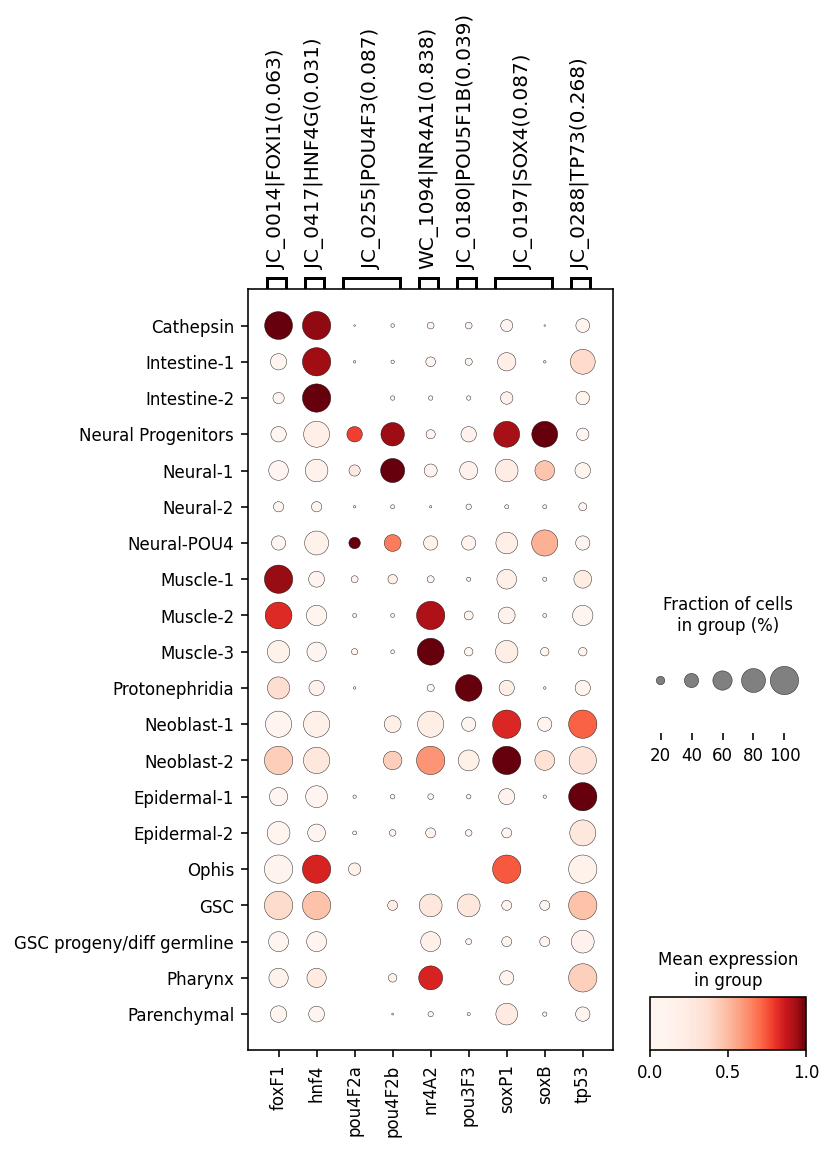

In [44]:
pOrder = np.concatenate( [ smedGeneMap[motif] for motif in plotMotifs ] )
gOrder = [ smedNameMap[p] for p in pOrder ]
intervals = []
i = 0
for motif in plotMotifs:
    n = len( smedGeneMap[motif] )
    j = i + n - 1
    intervals.append( (i,j) )
    i = j + 1
    
g = sc.pl.dotplot( adataGexP, groupby='GroupFigure', use_raw=False, show=False,
               mean_only_expressed=False, figsize=(5,7), standard_scale='var', 
               dot_min=0, dot_max=1, categories_order=uLabels, # layer='knnAvg',
               var_names=pOrder, cmap=custom_cmap, 
               var_group_labels=plotMotifs, var_group_positions=intervals )
g['mainplot_ax'].set_xticklabels(gOrder)
plt.savefig( 'Figures/Smed.cluster_motif_comparison_gex_20250911_trimmed.svg', format='svg' )
plt.show()

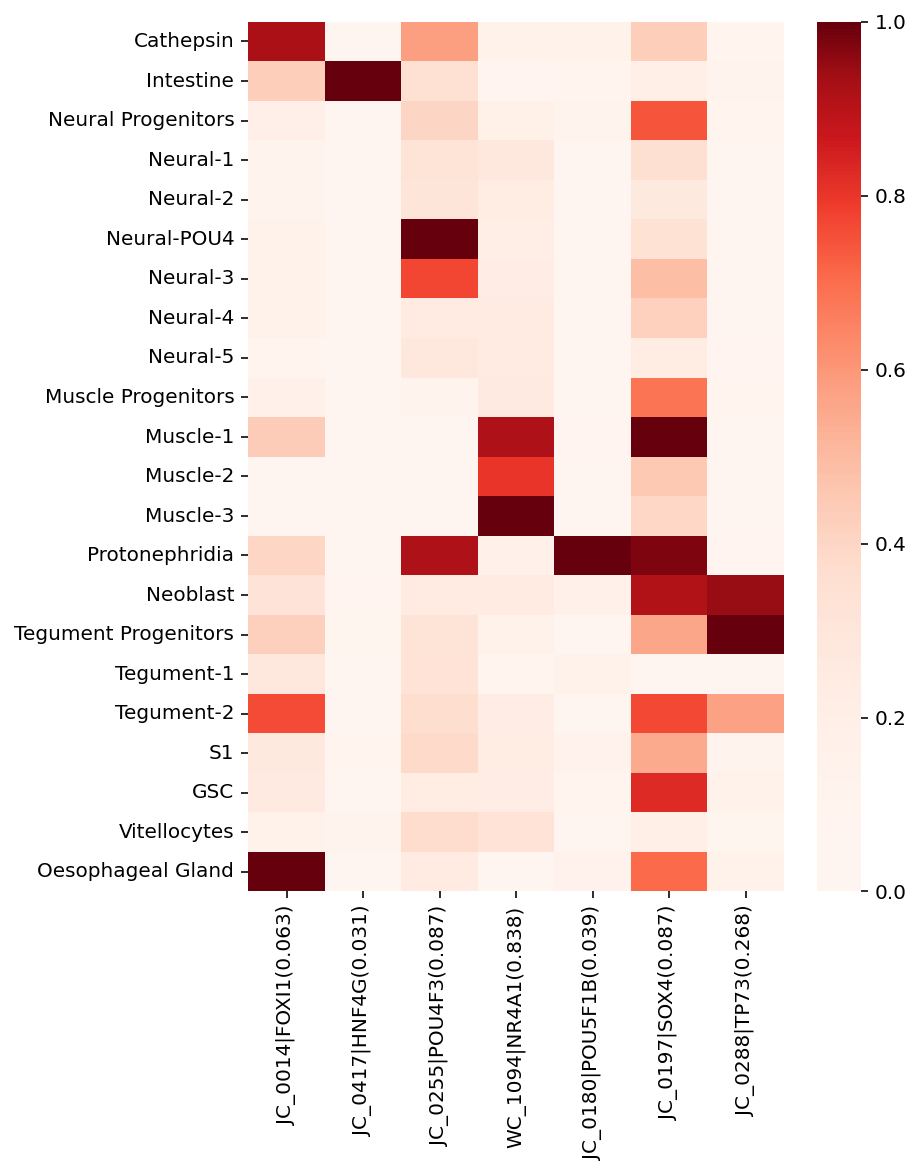

In [45]:
# uLabels = np.array(['Cathepsin','Intestine','S1','GSC','Neoblast',
#                     'Neural Progenitors','Neural-1','Neural-2','Neural-POU4','Neural-3','Neural-4','Neural-5',
#                     'Muscle Progenitors','Muscle-1','Muscle-2','Muscle-3','Tegument Progenitors',
#                     'Tegument-1','Tegument-2','Vitellocytes','Oesophageal Gland','Protonephridia'])
uLabels = np.array(['Cathepsin','Intestine','Neural Progenitors','Neural-1','Neural-2','Neural-POU4',
                    'Neural-3','Neural-4','Neural-5','Muscle Progenitors','Muscle-1','Muscle-2','Muscle-3',
                    'Protonephridia','Neoblast','Tegument Progenitors','Tegument-1','Tegument-2','S1','GSC',
                    'Vitellocytes','Oesophageal Gland'])
X = np.zeros( (uLabels.size,len(plotMotifs)) )
for i, grp in enumerate( uLabels ):
    X[i,:] = adataMotifS[adataMotifS.obs.GroupFigure==grp,plotMotifs].X.mean(0)
    
X = pd.DataFrame( data=X, index=uLabels, columns=plotMotifs )
X = X - X.min(0)
X = X / X.max(0)
fig = plt.figure( figsize=(6,8) )
sns.heatmap( X, cmap=custom_cmap, ax=fig.gca() )
plt.savefig( 'Figures/Sman.cluster_motif_comparison_devs_20250911_trimmed.svg', format='svg' )
plt.show()

In [38]:
smanGeneMap = { 'JC_0014|FOXI1(0.063)':['Smp_076300','Smp_054350'],
                'JC_0012|ELK3(0.088)':['Smp_126530','Smp_342280'],
                'JC_0417|HNF4G(0.031)':['Smp_174700'],
                'JC_0073|GATA3(0.177)':['Smp_159560'],
                'JC_0083|NKX2-8(0.092)':['Smp_347780'],
                'JC_0197|SOX4(0.087)':['Smp_076600'],
                'JC_0288|TP73(0.268)':['Smp_139530'], 
                'JC_0255|POU4F3(0.087)':['Smp_340200'],
                'WC_1094|NR4A1(0.838)':['Smp_139200'],
                'JC_0200|MYOG(0.115)':['Smp_167400'],
                'JC_0341|GATA20(0.052)':['Smp_159560'],
                'JC_0292|Sox11(0.000)':['Smp_346620'],
                'JC_0276|PAX1(0.064)':['Smp_142940','Smp_345980'],
                'JC_0364|FERD3L(0.000)':['Smp_311860'],
                'JC_0180|POU5F1B(0.039)':['Smp_344230'],
                'JC_0176|FOXC2(0.237)':['Smp_331700'] }

In [39]:
smanNameMap = { 'Smp_076300': 'foxF1',
                'Smp_054350': 'foxD3',
                'Smp_342280': 'etv1',
                'Smp_126530': 'ets1',
                'Smp_174700': 'hnf4',
                'Smp_159560': 'delete',
                'Smp_347780': 'nkx2-5',
                'Smp_076600': 'soxl1',
                'Smp_139530': 'tp53',
                'Smp_340200': 'pou4F2',
                'Smp_139200': 'nr4A2',
                'Smp_167400': 'myod1',
                'Smp_346620': 'soxl2',
                'Smp_142940': 'pax6l',
                'Smp_345980': 'pax6',
                'Smp_311860': 'delete',
                'Smp_344230': 'pou',
                'Smp_331700': 'foxA' }

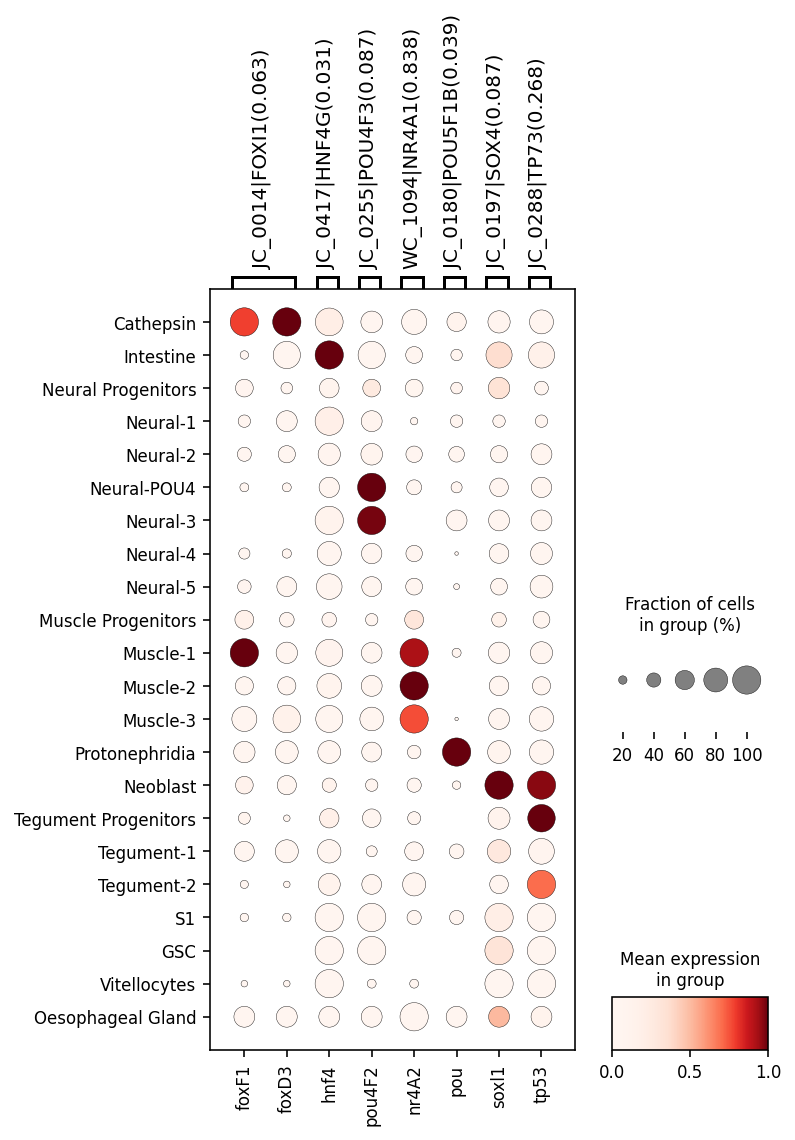

In [46]:
pOrder = np.concatenate( [ smanGeneMap[motif] for motif in plotMotifs ] )
gOrder = [ smanNameMap[p] for p in pOrder ]
intervals = []
i = 0
for motif in plotMotifs:
    n = len( smanGeneMap[motif] )
    j = i + n - 1
    intervals.append( (i,j) )
    i = j + 1
    
g = sc.pl.dotplot( adataGexS, groupby='GroupFigure', use_raw=False, show=False,
               mean_only_expressed=False, figsize=(5,7), standard_scale='var', 
               dot_min=0, dot_max=1, categories_order=uLabels, # layer='knnAvg',
               var_names=pOrder, cmap=custom_cmap, 
               var_group_labels=plotMotifs, var_group_positions=intervals )
g['mainplot_ax'].set_xticklabels(gOrder)
plt.savefig( 'Figures/Sman.cluster_motif_comparison_gex_20250911_trimmed.svg', format='svg' )
plt.show()